# 03 — Topic Summary

Topic identification from the original LDA model (`02_topic_modeling-Copy1.ipynb` + `output/lda_vis_chn.html`).

Topics are identified using pyLDAvis display ordering with loglift-ranked terms to cut through boilerplate and surface substantive case-content signals. The pie chart mirrors the cluster structure used in the relationship tree.

## 1. Imports & Chinese Font Setup

In [1]:
import json, re
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm

_cjk = ['PingFang SC', 'Heiti SC', 'STHeiti', 'SimHei', 'Noto Sans CJK SC']
_avail = {f.name for f in fm.fontManager.ttflist}
_font = next((f for f in _cjk if f in _avail), None)
if _font:
    matplotlib.rcParams['font.family'] = _font
    print(f'Using CJK font: {_font}')
else:
    print('No CJK font found — Chinese labels may render as boxes')
matplotlib.rcParams['axes.unicode_minus'] = False

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'


Using CJK font: STHeiti


## 2. Parse `lda_vis_chn.html` (Original Model)

In [2]:
with open("../output/lda_vis_chn.html") as f:
    html = f.read()

match = re.search(r'var ldavis_\w+_data = ({.*?});', html, re.DOTALL)
lda_data = json.loads(match.group(1))
tinfo    = lda_data["tinfo"]
mds      = lda_data["mdsDat"]

print("topic.order (display -> gensim 1-indexed):", lda_data["topic.order"])
print("\nDisplay topic corpus shares:")
for t, f in zip(mds["topics"], mds["Freq"]):
    print(f"  Display Topic {t}: {f:.2f}%")


topic.order (display -> gensim 1-indexed): [4, 3, 2, 5, 1]

Display topic corpus shares:
  Display Topic 1: 23.91%
  Display Topic 2: 23.89%
  Display Topic 3: 22.76%
  Display Topic 4: 19.74%
  Display Topic 5: 9.70%


In [3]:
# Extract top terms per display topic by both loglift and frequency
topic_terms = {}
for tn in range(1, 6):
    cat = f"Topic{tn}"
    rows = [(tinfo["Term"][i], round(tinfo["Freq"][i], 2), round(tinfo["loglift"][i], 3))
            for i, c in enumerate(tinfo["Category"]) if c == cat]
    topic_terms[tn] = {
        "loglift": [t for t, f, l in sorted(rows, key=lambda x: -x[2])[:10]],
        "freq":    [t for t, f, l in sorted(rows, key=lambda x: -x[1])[:10]],
    }

for tn in range(1, 6):
    print(f"Display Topic {tn}")
    print(f"  loglift: {topic_terms[tn]['loglift']}")
    print(f"  freq:    {topic_terms[tn]['freq']}")
    print()


Display Topic 1
  loglift: ['出借', '补救措施', '公司财务', '专用章', '授权书', '垫款', '强强', '兽药', '生态旅游', '青苗']
  freq:    ['转款', '出借', '欠付', '履行合同', '公章', '补救措施', '公司财务', '借条', '专用章', '授权书']

Display Topic 2
  loglift: ['共融', '侵权行为', '致歉', '肖像权', '百科', '版面', '推送', '二维码', '停缴', '工作大队']
  freq:    ['民事', '退役', '运动员', '民事裁定', '体育局', '微信', '补偿费', '传票', '截图', '抚慰金']

Display Topic 3
  loglift: ['体校', '自行车队', '在编', '违纪', '工资标准', '津贴', '合同书', '初字', '适用', '报名条件']
  freq:    ['体育局', '运动队', '工资待遇', '择业', '人事厅', '补偿金', '人事科', '人事处', '补发', '离队']

Display Topic 4
  loglift: ['发号', '公派', '打球', '劳人', '签收', '意见书', '半月板', '原省', '函号', '时应']
  freq:    ['民事判决', '体育局', '主体资格', '择业', '发号', '退役费', '人事部', '人事部门', '人事厅', '国家体育总局']

Display Topic 5
  loglift: ['住宿费', '椎间盘', '补助费', '工作队', '护理费', '营养费', '伤残', '预交', '案由', '食宿费']
  freq:    ['护理费', '住宿费', '营养费', '预交', '补偿金', '椎间盘', '补助费', '体工队', '工作队', '鉴定费']



## 3. Topic Identification

The original model (original STOPWORDS, `lda_vis_chn.html`) produces five display topics ordered by corpus share. Terms are identified using **loglift** (exclusivity of the term to this topic) rather than raw frequency, because frequency is inflated by boilerplate that survived the original STOPWORDS list (`民事`, `民事裁定`, `民事判决` etc.). The substantive signal is in the high-loglift terms.

Gensim model raw output (`02_topic_modeling-Copy1.ipynb`) is used to cross-validate:

| topic.order mapping | Gensim idx (0-based) | Top loglift terms |
|---|---|---|
| Display T1 (23.9%) | 3 | 出借, 补救措施, 公司财务, 专用章, 授权书 |
| Display T2 (23.9%) | 2 | 侵权行为, 致歉, 肖像权, 推送, 二维码 |
| Display T3 (22.8%) | 1 | 在编, 违纪, 工资标准, 津贴, 体校 |
| Display T4 (19.7%) | 4 | 公派, 打球, 发号, 签收, 主体资格 |
| Display T5 (9.7%)  | 0 | 住宿费, 椎间盘, 护理费, 营养费, 伤残 |

In [4]:
# topic.order: [4, 3, 2, 5, 1]
# Display T1 = Gensim topic 4 (Python idx 3)
# Display T2 = Gensim topic 3 (Python idx 2)
# Display T3 = Gensim topic 2 (Python idx 1)
# Display T4 = Gensim topic 5 (Python idx 4)
# Display T5 = Gensim topic 1 (Python idx 0)

TOPIC_META = {
    1: {
        "zh": "商业合同违约与债务追偿",
        "en": "Commercial Contract Breach & Debt Recovery",
        "pct": 23.91,
        "gensim_idx": 3,
        "cluster": "commercial",
        "top_terms_ll": ["出借","补救措施","公司财务","专用章","授权书","垫款","兽药","强强"],
        "top_terms_fr": ["转款","欠付","出借","履行合同","公章","补救措施","公司财务","借条"],
        "description": (
            "Commercial and financial disputes (23.9%). Athletes or sports "
            "organisations as parties to supply/service/loan contracts. Key markers: "
            "IOUs (借条), authorisation letters (授权书), overdue transfers (转款/欠付), "
            "corporate seals (专用章). Includes agriculture-adjacent ventures linked "
            "to sports clubs (兽药 veterinary drugs, 垫款 advances)."
        ),
    },
    2: {
        "zh": "网络侵权与运动员肖像权纠纷",
        "en": "Online Infringement & Athlete Image-Rights Disputes",
        "pct": 23.89,
        "gensim_idx": 2,
        "cluster": "sports",
        "top_terms_ll": ["侵权行为","致歉","肖像权","推送","二维码","百科","版面","共融"],
        "top_terms_fr": ["微信","截图","抚慰金","传票","补偿费","肖像权","侵权行为","致歉"],
        "description": (
            "Athlete image and online-speech cases (23.9%). Unauthorised commercial use "
            "of athlete likeness via WeChat (微信), QR codes (二维码), screenshots (截图), "
            "and online encyclopaedia edits (百科). Tort vocabulary (侵权行为, 致歉) "
            "dominates loglift; raw-frequency inflated by boilerplate 民事/民事裁定."
        ),
    },
    3: {
        "zh": "运动队编制人事与薪资待遇",
        "en": "Sports-Team Personnel Status & Wage Benefits",
        "pct": 22.76,
        "gensim_idx": 1,
        "cluster": "sports",
        "top_terms_ll": ["在编","违纪","工资标准","津贴","体校","自行车队","合同书","离队"],
        "top_terms_fr": ["体育局","运动队","工资待遇","择业","人事厅","补偿金","补发","离队"],
        "description": (
            "Internal sports-system HR disputes (22.8%). Staffing status (在编 on-roster), "
            "disciplinary proceedings (违纪), wage scales (工资标准), allowances (津贴), "
            "and transfer/departure (离队). The provincial sports bureaucracy "
            "(人事厅, 体育局, 运动队) is the primary institutional actor."
        ),
    },
    4: {
        "zh": "运动员退役安置与行政诉讼",
        "en": "Athlete Retirement Placement & Administrative Litigation",
        "pct": 19.74,
        "gensim_idx": 4,
        "cluster": "sports",
        "top_terms_ll": ["公派","打球","发号","签收","意见书","主体资格","半月板","原省"],
        "top_terms_fr": ["主体资格","择业","退役费","国家体育总局","人事部","人事厅","发号"],
        "description": (
            "Athlete retirement and administrative standing disputes (19.7%). Cases disputing "
            "post-career placement (择业), overseas-assignment returns (公派), and whether "
            "the defendant Sports Bureau has procedural standing (主体资格) to be sued. "
            "Bridges factual retirement claims (退役费) with administrative law."
        ),
    },
    5: {
        "zh": "运动伤害医疗赔偿",
        "en": "Sports Injury & Medical Compensation",
        "pct": 9.70,
        "gensim_idx": 0,
        "cluster": "sports",
        "top_terms_ll": ["住宿费","椎间盘","护理费","营养费","伤残","补助费","工作队","食宿费"],
        "top_terms_fr": ["护理费","住宿费","营养费","预交","补偿金","椎间盘","补助费","鉴定费"],
        "description": (
            "Sports injury compensation (9.7%). Physical injury claims from training or "
            "competition: nursing (护理费), nutrition (营养费), accommodation during "
            "treatment (住宿费), disability assessment (伤残). Sports-specific injuries "
            "confirmed by medical terms: 椎间盘 (disc herniation), 半月板 (meniscus)."
        ),
    },
}

for tn, m in TOPIC_META.items():
    print(f"Display T{tn} ({m['pct']}%)  [{m['cluster']}]")
    print(f"  ZH: {m['zh']}")
    print(f"  EN: {m['en']}")
    print(f"  Key (loglift): {', '.join(m['top_terms_ll'][:5])}")
    print()


Display T1 (23.91%)  [commercial]
  ZH: 商业合同违约与债务追偿
  EN: Commercial Contract Breach & Debt Recovery
  Key (loglift): 出借, 补救措施, 公司财务, 专用章, 授权书

Display T2 (23.89%)  [sports]
  ZH: 网络侵权与运动员肖像权纠纷
  EN: Online Infringement & Athlete Image-Rights Disputes
  Key (loglift): 侵权行为, 致歉, 肖像权, 推送, 二维码

Display T3 (22.76%)  [sports]
  ZH: 运动队编制人事与薪资待遇
  EN: Sports-Team Personnel Status & Wage Benefits
  Key (loglift): 在编, 违纪, 工资标准, 津贴, 体校

Display T4 (19.74%)  [sports]
  ZH: 运动员退役安置与行政诉讼
  EN: Athlete Retirement Placement & Administrative Litigation
  Key (loglift): 公派, 打球, 发号, 签收, 意见书

Display T5 (9.7%)  [sports]
  ZH: 运动伤害医疗赔偿
  EN: Sports Injury & Medical Compensation
  Key (loglift): 住宿费, 椎间盘, 护理费, 营养费, 伤残



## 4. Summary Table

In [5]:
rows = []
for tn, m in TOPIC_META.items():
    rows.append({
        "Display T": f"T{tn}",
        "Corpus %": f"{m['pct']:.1f}%",
        "Cluster": "Sports-Specific" if m["cluster"]=="sports" else "Commercial/Financial",
        "Chinese Title": m["zh"],
        "Top Terms (loglift)": ", ".join(m["top_terms_ll"][:5]),
        "English Theme": m["en"],
    })

summary = pd.DataFrame(rows).set_index("Display T")
pd.set_option("display.max_colwidth", 55)
print(summary.to_string())
summary


          Corpus %               Cluster  Chinese Title       Top Terms (loglift)                                             English Theme
Display T                                                                                                                                  
T1           23.9%  Commercial/Financial    商业合同违约与债务追偿  出借, 补救措施, 公司财务, 专用章, 授权书                Commercial Contract Breach & Debt Recovery
T2           23.9%       Sports-Specific  网络侵权与运动员肖像权纠纷    侵权行为, 致歉, 肖像权, 推送, 二维码       Online Infringement & Athlete Image-Rights Disputes
T3           22.8%       Sports-Specific   运动队编制人事与薪资待遇      在编, 违纪, 工资标准, 津贴, 体校              Sports-Team Personnel Status & Wage Benefits
T4           19.7%       Sports-Specific   运动员退役安置与行政诉讼       公派, 打球, 发号, 签收, 意见书  Athlete Retirement Placement & Administrative Litigation
T5            9.7%       Sports-Specific       运动伤害医疗赔偿    住宿费, 椎间盘, 护理费, 营养费, 伤残                      Sports Injury & Medical Compensation


,Corpus %,Cluster,Chinese Title,Top Terms (loglift),English Theme
Display T,,,,,
T1,23.9%,Commercial/Financial,商业合同违约与债务追偿,"出借, 补救措施, 公司财务, 专用章, 授权书",Commercial Contract Breach & Debt Recovery
T2,23.9%,Sports-Specific,网络侵权与运动员肖像权纠纷,"侵权行为, 致歉, 肖像权, 推送, 二维码",Online Infringement & Athlete Image-Rights Disputes
T3,22.8%,Sports-Specific,运动队编制人事与薪资待遇,"在编, 违纪, 工资标准, 津贴, 体校",Sports-Team Personnel Status & Wage Benefits
T4,19.7%,Sports-Specific,运动员退役安置与行政诉讼,"公派, 打球, 发号, 签收, 意见书",Athlete Retirement Placement & Administrative Litig...
T5,9.7%,Sports-Specific,运动伤害医疗赔偿,"住宿费, 椎间盘, 护理费, 营养费, 伤残",Sports Injury & Medical Compensation


## 5. Cluster Breakdown

In [ ]:
sports_pct = sum(m["pct"] for m in TOPIC_META.values() if m["cluster"] == "sports")
comm_pct   = sum(m["pct"] for m in TOPIC_META.values() if m["cluster"] == "commercial")

print("Cluster shares (original model):")
print(f"  Sports-Specific Disputes  : {sports_pct:.1f}%  (T2 + T3 + T4 + T5)")
print(f"  Commercial/Financial      : {comm_pct:.1f}%  (T1)")
print(f"  Total                     : {sports_pct+comm_pct:.1f}%")


## 6. Topic Distribution Pie Chart

Recreated from `pie_chart.ipynb` with updated topic labels and percentages from `lda_vis_chn.html`. Topics ordered so the sports-specific cluster (T2 → T3 → T4 → T5) sits together on the left, and the commercial cluster (T1) on the right.

Text(0, 0, 'Athlete\nCourt Cases\n(n = 79)')

/var/folders/9c/c84wrldd0wgbdtr9v0n9gp100000gn/T/ipykernel_26938/394140554.py:46: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(mpatches.Wedge(


/var/folders/9c/c84wrldd0wgbdtr9v0n9gp100000gn/T/ipykernel_26938/394140554.py:50: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(mpatches.Wedge(


Text(-1.1602213382720947, -1.2425322532653809, 'Sports-Specific\nDisputes')

Text(1.1602212190628052, 1.24253249168396, 'Commercial /\nFinancial Disputes')

(-2.1, 2.1)

(-2.2, 2.1)

(np.float64(-2.1), np.float64(2.1), np.float64(-2.2), np.float64(2.1))

Text(0.5, 1.0, 'LDA Topic Distribution — Athlete Court Cases (Original Model)\n(outer arc = dispute cluster; slice area ∝ corpus share)')

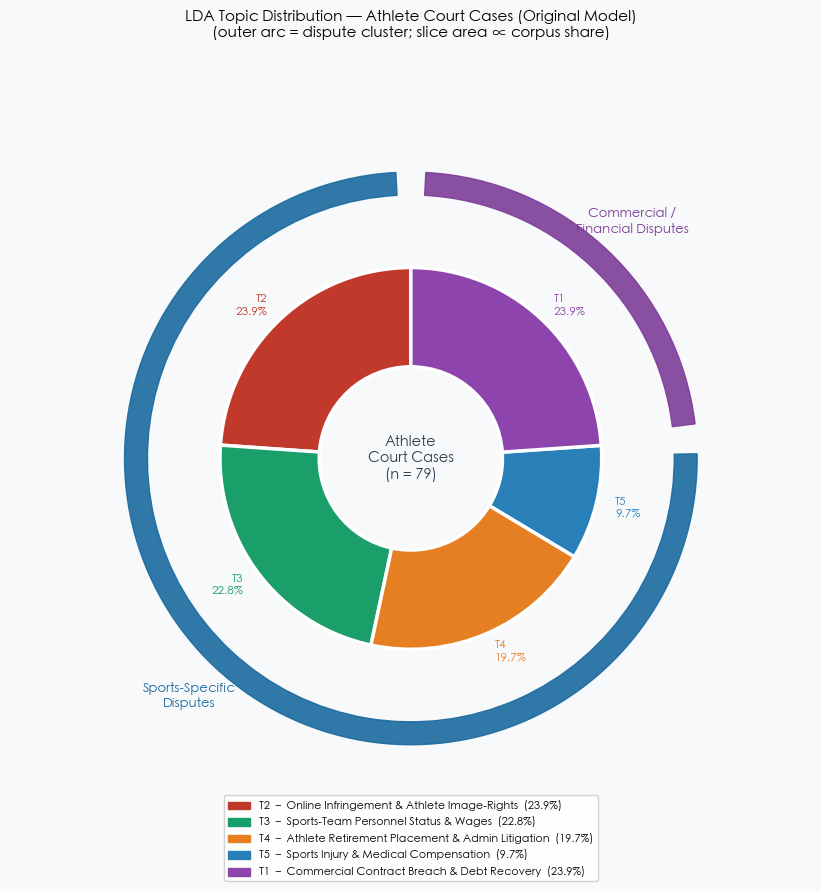

Saved -> ../output/topic_pie_original.png


In [6]:
COLORS = {
    1: "#8E44AD",   # purple  — commercial/debt
    2: "#C0392B",   # red     — image rights
    3: "#1A9E6A",   # green   — personnel/wages
    4: "#E67E22",   # orange  — retirement/admin
    5: "#2980B9",   # blue    — medical injury
}
SPORTS_COLOR = "#1A6A9E"
COMM_COLOR   = "#7D3C98"

# Order: sports cluster (T2,T3,T4,T5) then commercial (T1), starting from top
topic_order = [2, 3, 4, 5, 1]
pcts        = [TOPIC_META[t]["pct"] for t in topic_order]
wedge_labels = [f"T{t}\n{TOPIC_META[t]['pct']:.1f}%" for t in topic_order]

fig, ax = plt.subplots(figsize=(10, 9))
ax.set_aspect("equal")
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")

wedges, texts = ax.pie(
    pcts,
    labels=wedge_labels,
    colors=[COLORS[t] for t in topic_order],
    startangle=90,
    labeldistance=1.10,
    wedgeprops=dict(edgecolor="white", linewidth=2.5, width=0.52),
    textprops=dict(fontsize=8.5, fontweight="bold"),
)
for text, tn in zip(texts, topic_order):
    text.set_color(COLORS[tn])

ax.text(0, 0, "Athlete\nCourt Cases\n(n = 79)",
        ha="center", va="center", fontsize=10.5,
        fontweight="bold", color="#2C3E50")

# ── outer category arcs ─────────────────────────────────────────────────────
# Sports cluster = wedges 0–3 (T2,T3,T4,T5); commercial = wedge 4 (T1)
sports_t1 = wedges[0].theta1   # start of T2 = 90°
sports_t2 = wedges[3].theta2   # end of T5
comm_t1   = wedges[4].theta1   # start of T1
comm_t2   = wedges[4].theta2   # end of T1

ARC_INNER, ARC_OUTER, GAP = 1.38, 1.50, 3.0

ax.add_patch(mpatches.Wedge(
    (0, 0), ARC_OUTER, sports_t1 + GAP, sports_t2 - GAP,
    width=ARC_OUTER - ARC_INNER, color=SPORTS_COLOR, alpha=0.90, edgecolor="none",
))
ax.add_patch(mpatches.Wedge(
    (0, 0), ARC_OUTER, comm_t1 + GAP, comm_t2 - GAP,
    width=ARC_OUTER - ARC_INNER, color=COMM_COLOR,   alpha=0.90, edgecolor="none",
))

LABEL_R    = 1.70
sports_mid = np.radians((sports_t1 + sports_t2) / 2)
comm_mid   = np.radians((comm_t1   + comm_t2)   / 2)

ax.text(LABEL_R * np.cos(sports_mid), LABEL_R * np.sin(sports_mid),
        "Sports-Specific\nDisputes",
        ha="center", va="center", fontsize=9.5, fontweight="bold", color=SPORTS_COLOR)
ax.text(LABEL_R * np.cos(comm_mid), LABEL_R * np.sin(comm_mid),
        "Commercial /\nFinancial Disputes",
        ha="center", va="center", fontsize=9.5, fontweight="bold", color=COMM_COLOR)

ax.set_xlim(-2.1, 2.1)
ax.set_ylim(-2.2, 2.1)
ax.axis("off")

legend_handles = [
    mpatches.Patch(color=COLORS[2], label="T2 – Online Infringement & Athlete Image-Rights  (23.9%)"),
    mpatches.Patch(color=COLORS[3], label="T3 – Sports-Team Personnel Status & Wages  (22.8%)"),
    mpatches.Patch(color=COLORS[4], label="T4 – Athlete Retirement Placement & Admin Litigation  (19.7%)"),
    mpatches.Patch(color=COLORS[5], label="T5 – Sports Injury & Medical Compensation  (9.7%)"),
    mpatches.Patch(color=COLORS[1], label="T1 – Commercial Contract Breach & Debt Recovery  (23.9%)"),
]
ax.legend(handles=legend_handles, loc="lower center", ncol=1,
          fontsize=8, framealpha=0.85, edgecolor="#ccc",
          bbox_to_anchor=(0.5, -0.01))

ax.set_title(
    "LDA Topic Distribution — Athlete Court Cases (Original Model)\n"
    "(outer arc = dispute cluster; slice area ∝ corpus share)",
    fontsize=11, fontweight="bold", pad=14,
)

plt.tight_layout()
plt.savefig("../output/topic_pie_original.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> ../output/topic_pie_original.png")
